# NLP Project 6: News Article Classification

**Problem Statement:** A news website publishes articles from different domains such as sports, politics, technology, entertainment, and business. As the number of articles increases daily, manually organizing them into categories becomes difficult and time-consuming. In this project, we build a simple NLP-based text classification system that automatically categorizes news articles.

**Tasks covered in this notebook:**
1. Collect news article dataset
2. Preprocess article text
3. Build text classification model
4. Categorize articles automatically
5. Evaluate model performance


## Step 0: Import Libraries

We use `pandas` for data handling, `nltk` for basic text preprocessing, and `scikit-learn` for feature extraction, modeling, and evaluation.

In [2]:

# !pip install nltk scikit-learn pandas matplotlib seaborn

import pandas as pd
import numpy as np
import re
import random
import string

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

random.seed(42)
np.random.seed(42)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Task 1: Collect News Article Dataset

For a real-world project, you would collect articles using a news API (like NewsAPI) or a public dataset (like the BBC News dataset or 20 Newsgroups).

To keep this notebook **self-contained and runnable without internet access**, we generate a small sample dataset ourselves by combining topic-specific sentence snippets into short "articles" for 5 categories: **Sports, Politics, Technology, Entertainment, Business**.


In [3]:

topic_snippets = {
    "Sports": [
        "The football team secured a thrilling victory in the final match.",
        "The star player scored a hat-trick to lead the team to the championship.",
        "Fans cheered as the national cricket team won the series.",
        "The coach praised the players for their outstanding teamwork.",
        "The athlete broke the national record in the 100m sprint.",
        "The basketball tournament concluded with a nail-biting finish.",
        "Injuries have kept several key players out of the upcoming season.",
        "The tennis champion successfully defended her title this year.",
        "The stadium was packed as thousands gathered to watch the derby.",
        "The team's defense was praised for a strong performance in the playoffs.",
    ],
    "Politics": [
        "The government announced a new policy to boost economic growth.",
        "Opposition leaders criticized the proposed reforms in parliament.",
        "The election commission released the schedule for upcoming polls.",
        "The president addressed the nation regarding new foreign policy measures.",
        "Lawmakers debated the budget allocation for the next fiscal year.",
        "The prime minister met with foreign delegates to discuss trade relations.",
        "Protesters gathered outside parliament demanding policy changes.",
        "The senate passed a new bill after weeks of negotiation.",
        "Political analysts weighed in on the implications of the new law.",
        "The ruling party secured a majority in the recent state elections.",
    ],
    "Technology": [
        "The company unveiled its latest smartphone with advanced camera features.",
        "Researchers developed a new artificial intelligence model for medical diagnosis.",
        "The tech giant announced a major update to its cloud computing platform.",
        "A new startup raised significant funding to expand its software products.",
        "Engineers demonstrated a breakthrough in battery technology for electric vehicles.",
        "The social media platform introduced new privacy features for users.",
        "Cybersecurity experts warned about a rise in phishing attacks.",
        "The company launched a new laptop with improved processing power.",
        "Scientists are exploring quantum computing applications in cryptography.",
        "The app update includes performance improvements and bug fixes.",
    ],
    "Entertainment": [
        "The blockbuster movie topped the box office in its opening weekend.",
        "The singer released a new album that quickly climbed the music charts.",
        "The award show celebrated outstanding achievements in film and television.",
        "The actor was praised for his powerful performance in the drama series.",
        "The streaming platform announced a new season of the popular show.",
        "Fans eagerly awaited the trailer release for the upcoming film.",
        "The music festival attracted thousands of visitors from around the world.",
        "The director shared insights into the making of the acclaimed film.",
        "The celebrity couple announced their engagement at a public event.",
        "The theater production received rave reviews from critics.",
    ],
    "Business": [
        "The company reported a significant increase in quarterly profits.",
        "Stock markets rallied following positive economic indicators.",
        "The retail chain announced plans to open new stores nationwide.",
        "Investors reacted positively to the merger announcement between the two firms.",
        "The central bank adjusted interest rates to control inflation.",
        "The startup secured a major investment round led by venture capitalists.",
        "The manufacturing sector showed signs of recovery this quarter.",
        "The company's shares dropped after disappointing earnings results.",
        "Trade negotiations between the two countries reached a new agreement.",
        "The CEO outlined a new strategy to expand into international markets.",
    ],
}

def generate_article(category, n_sentences=4):
    """Randomly combine snippets from a category to form a short article."""
    sentences = random.sample(topic_snippets[category], k=min(n_sentences, len(topic_snippets[category])))
    return " ".join(sentences)

# Generate a dataset: 60 articles per category = 300 articles total
rows = []
for category in topic_snippets:
    for _ in range(60):
        n_sent = random.randint(2, 4)
        article = generate_article(category, n_sentences=n_sent)
        rows.append({"text": article, "category": category})

df = pd.DataFrame(rows).sample(frac=1, random_state=42).reset_index(drop=True)
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (300, 2)


,text,category
0,The award show celebrated outstanding achievem...,Entertainment
1,The company's shares dropped after disappointi...,Business
2,The app update includes performance improvemen...,Technology
3,The star player scored a hat-trick to lead the...,Sports
4,The music festival attracted thousands of visi...,Entertainment


In [4]:

df.to_csv("news_articles_dataset.csv", index=False)
df['category'].value_counts()

,count
category,
Entertainment,60
Business,60
Technology,60
Sports,60
Politics,60


/tmp/ipykernel_477/3730692585.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='category', data=df, order=df['category'].value_counts().index, palette='viridis')


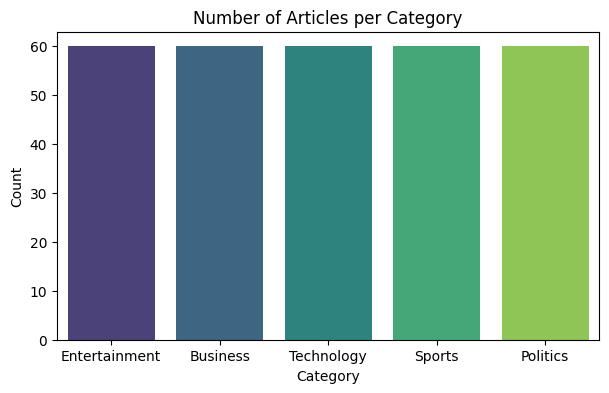

In [5]:
plt.figure(figsize=(7,4))
sns.countplot(x='category', data=df, order=df['category'].value_counts().index, palette='viridis')
plt.title("Number of Articles per Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

## Task 2: Preprocess Article Text

Before feeding text into a machine learning model, we clean it up:
- Lowercase all text
- Remove punctuation and numbers
- Remove stopwords (common words like "the", "is", "and" that don't carry much meaning)
- Remove extra whitespace

In [6]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()                                  # lowercase
    text = re.sub(r'[^a-z\s]', ' ', text)                 # remove punctuation/numbers
    tokens = text.split()                                 # tokenize by whitespace
    tokens = [word for word in tokens if word not in stop_words]  # remove stopwords
    return " ".join(tokens)

df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text']].head()

,text,clean_text
0,The award show celebrated outstanding achievem...,award show celebrated outstanding achievements...
1,The company's shares dropped after disappointi...,company shares dropped disappointing earnings ...
2,The app update includes performance improvemen...,app update includes performance improvements b...
3,The star player scored a hat-trick to lead the...,star player scored hat trick lead team champio...
4,The music festival attracted thousands of visi...,music festival attracted thousands visitors ar...


### Before vs after cleaning (example)

In [7]:
print("Original :", df['text'].iloc[0])
print()
print("Cleaned  :", df['clean_text'].iloc[0])

Original : The award show celebrated outstanding achievements in film and television. The director shared insights into the making of the acclaimed film. The singer released a new album that quickly climbed the music charts. The music festival attracted thousands of visitors from around the world.

Cleaned  : award show celebrated outstanding achievements film television director shared insights making acclaimed film singer released new album quickly climbed music charts music festival attracted thousands visitors around world


## Task 3: Build Text Classification Model

We'll turn the cleaned text into numerical features using **TF-IDF (Term Frequency–Inverse Document Frequency)**, then train two simple, beginner-friendly classifiers:

1. **Multinomial Naive Bayes** — a classic, fast baseline for text classification
2. **Logistic Regression** — a strong linear baseline that often performs very well on text data

We'll compare both and pick the better one.

In [8]:
# Split data into train and test sets
X = df['clean_text']
y = df['category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 240
Testing samples : 60


In [9]:
# Convert text to TF-IDF feature vectors
tfidf = TfidfVectorizer(max_features=3000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF matrix shape (train):", X_train_tfidf.shape)

TF-IDF matrix shape (train): (240, 277)


In [10]:
# Model 1: Multinomial Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_preds = nb_model.predict(X_test_tfidf)

# Model 2: Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
lr_preds = lr_model.predict(X_test_tfidf)

print("Naive Bayes Accuracy       :", round(accuracy_score(y_test, nb_preds), 3))
print("Logistic Regression Accuracy:", round(accuracy_score(y_test, lr_preds), 3))

Naive Bayes Accuracy       : 1.0
Logistic Regression Accuracy: 1.0


## Task 4: Categorize Articles Automatically

Now the trained model to automatically predict the category of brand-new, unseen articles — just like the news website would do for incoming content.

In [12]:

best_model = lr_model if accuracy_score(y_test, lr_preds) >= accuracy_score(y_test, nb_preds) else nb_model
best_model_name = "Logistic Regression" if best_model is lr_model else "Multinomial Naive Bayes"
print(f"Using best model: {best_model_name}")

def predict_category(article_text, model=best_model, vectorizer=tfidf):
    cleaned = clean_text(article_text)
    vec = vectorizer.transform([cleaned])
    prediction = model.predict(vec)[0]
    return prediction

sample_articles = [
    "The striker scored two goals to help his team win the championship match.",
    "The finance minister presented the new budget in parliament today.",
    "The company launched a new AI-powered chatbot for customer service.",
    "The movie premiere was attended by several famous celebrities.",
    "Shares of the company surged after strong quarterly earnings were announced.",
]

for article in sample_articles:
    category = predict_category(article)
    print(f"[{category:15}] {article}")

Using best model: Logistic Regression
[Sports         ] The striker scored two goals to help his team win the championship match.
[Politics       ] The finance minister presented the new budget in parliament today.
[Technology     ] The company launched a new AI-powered chatbot for customer service.
[Sports         ] The movie premiere was attended by several famous celebrities.
[Business       ] Shares of the company surged after strong quarterly earnings were announced.


## Task 5: Evaluate Model Performance


In [13]:
final_preds = best_model.predict(X_test_tfidf)

print(f"=== {best_model_name} — Classification Report ===\n")
print(classification_report(y_test, final_preds))

=== Logistic Regression — Classification Report ===

               precision    recall  f1-score   support

     Business       1.00      1.00      1.00        12
Entertainment       1.00      1.00      1.00        12
     Politics       1.00      1.00      1.00        12
       Sports       1.00      1.00      1.00        12
   Technology       1.00      1.00      1.00        12

     accuracy                           1.00        60
    macro avg       1.00      1.00      1.00        60
 weighted avg       1.00      1.00      1.00        60



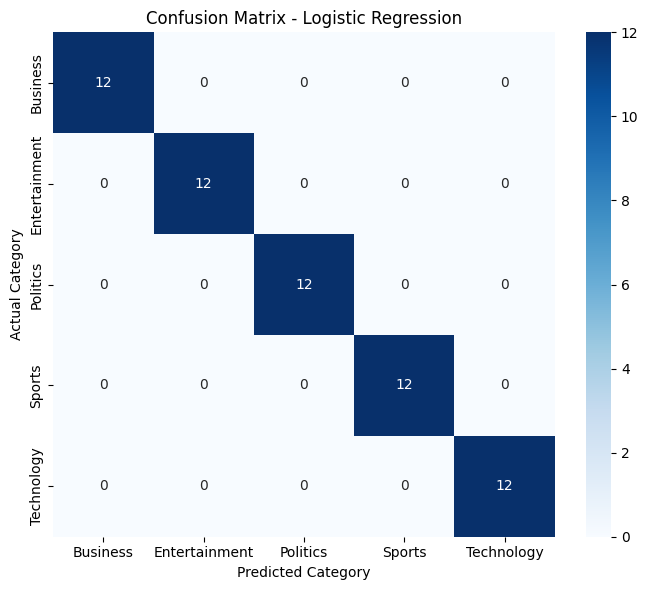

In [14]:
# Confusion Matrix
cm = confusion_matrix(y_test, final_preds, labels=best_model.classes_)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.tight_layout()
plt.show()

In [15]:
# Compare both models side by side
comparison = pd.DataFrame({
    "Model": ["Multinomial Naive Bayes", "Logistic Regression"],
    "Accuracy": [accuracy_score(y_test, nb_preds), accuracy_score(y_test, lr_preds)]
})
comparison

,Model,Accuracy
0,Multinomial Naive Bayes,1.0
1,Logistic Regression,1.0


## Conclusion



1. **Collected** a sample news article dataset across 5 categories (Sports, Politics, Technology, Entertainment, Business)
2. **Preprocessed** the text (lowercasing, removing punctuation, removing stopwords)
3. **Built** two text classification models using TF-IDF features — Naive Bayes and Logistic Regression
4. **Automatically categorized** new, unseen articles using the trained model
5. **Evaluated** performance using accuracy, a classification report, and a confusion matrix
